<a href="https://colab.research.google.com/github/thunderhoser/ml4rt/blob/master/examples_of_unresolvable_uncertainty.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install compatible versions of TensorFlow and TensorFlow Probability

After running this code cell, you will need to restart the runtime.  But after restarting the runtime, you will *not* need to run this code cell again.

In [1]:
!pip install -U tensorflow==2.15 tensorflow-probability==0.23.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.3/475.3 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 5.3 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.17.2
    Uninstalling wrapt-1.17.2:
      Successfully uninstalled wrapt-1.17.2
  Attempting uninstall: protobuf
    Found existing installati

# Import libraries

In [96]:
%matplotlib inline
import numpy
import keras
import tensorflow
from tensorflow.keras import backend as K
import tensorflow_probability as tf_prob
from tensorflow_probability.python.distributions import \
    kullback_leibler as kl_lib
from matplotlib import pyplot

# Define constants

In [12]:
SEPARATOR_STRING = '\n\n' + '*' * 50 + '\n\n'

FIGURE_WIDTH_INCHES = 7.5
FIGURE_HEIGHT_INCHES = 7.5

DEFAULT_FONT_SIZE = 16
pyplot.rc('font', size=DEFAULT_FONT_SIZE)
pyplot.rc('axes', titlesize=DEFAULT_FONT_SIZE)
pyplot.rc('axes', labelsize=DEFAULT_FONT_SIZE)
pyplot.rc('xtick', labelsize=DEFAULT_FONT_SIZE)
pyplot.rc('ytick', labelsize=DEFAULT_FONT_SIZE)
pyplot.rc('legend', fontsize=DEFAULT_FONT_SIZE)
pyplot.rc('figure', titlesize=DEFAULT_FONT_SIZE)

INSET_HISTOGRAM_FACE_COLOUR = numpy.full(3, 152. / 255)
INSET_HISTOGRAM_EDGE_COLOUR = numpy.full(3, 0.)
INSET_HISTOGRAM_EDGE_WIDTH = 1.

SSRAT_LINE_COLOUR = numpy.array([217, 95, 2], dtype=float) / 255
SSRAT_LINE_WIDTH = 3.

SKILL_LINE_COLOUR = numpy.array([117, 112, 179], dtype=float) / 255
SKILL_LINE_WIDTH = 3.
REFERENCE_LINE_WIDTH = 2.

# Define methods

In [101]:
def target_function_scenarios1and2(x1_values, x2_values):
    """Target function for scenarios 1 and 2.

    This is the correct function for producing y from x_1 and x_2.

    N = number of data points

    :param x1_values: length-N numpy array with values of predictor x_1.
    :param x2_values: length-N numpy array with values of predictor x_2.
    :return: y_values: length-N numpy array with values of target y.
    """

    y_values = (
        numpy.sin(2 * numpy.pi * x1_values) * numpy.exp(-1 * x1_values**2)
        + 0.5 * x1_values**3
        - numpy.tanh(2 * x1_values)
    )
    y_values = y_values + x2_values

    return y_values


def crps_loss(target_tensor, prediction_tensor):
    """Computes CRPS loss.

    E = number of data examples
    S = ensemble size

    :param target_tensor: E-by-1 tensor of actual values.
    :param prediction_tensor: E-by-1-by-S tensor of predicted values.
    :return: loss_value: Scalar CRPS.
    """

    mae_term = K.mean(K.abs(prediction_tensor - target_tensor), axis=-1)
    mapd_term = K.mean(
        K.abs(
            K.expand_dims(prediction_tensor, -1) -
            K.expand_dims(prediction_tensor, -2)
        ),
        axis=(-2, -1)
    )

    return K.mean(mae_term - 0.5 * mapd_term)


def create_crps_architecture(num_predictors):
    """Creates neural network with CRPS-LF approach to uncertainty quant.

    :param num_predictors: Number of predictor variables.
    :return: model_object: Compiled instance of `keras.models.Model`, ready to
        train.
    """

    l2_object = keras.regularizers.l1_l2(l1=0., l2=1e-6)
    input_layer_object = keras.layers.Input(shape=(num_predictors,))

    # First dense layer.
    current_layer_object = keras.layers.Dense(
        100,
        activation=None,
        use_bias=True,
        kernel_initializer='glorot_uniform',
        bias_initializer='zeros',
        kernel_regularizer=l2_object,
        bias_regularizer=l2_object
    )(input_layer_object)
    current_layer_object = keras.layers.LeakyReLU(alpha=0.2)(
        current_layer_object
    )
    current_layer_object = keras.layers.BatchNormalization(
        axis=-1, momentum=0.99, epsilon=0.001, center=True, scale=True
    )(current_layer_object)

    # Second dense layer.
    current_layer_object = keras.layers.Dense(
        100,
        activation=None,
        use_bias=True,
        kernel_initializer='glorot_uniform',
        bias_initializer='zeros',
        kernel_regularizer=l2_object,
        bias_regularizer=l2_object
    )(current_layer_object)
    current_layer_object = keras.layers.LeakyReLU(alpha=0.2)(
        current_layer_object
    )
    current_layer_object = keras.layers.BatchNormalization(
        axis=-1, momentum=0.99, epsilon=0.001, center=True, scale=True
    )(current_layer_object)

    # Third dense layer.
    current_layer_object = keras.layers.Dense(
        100,
        activation=None,
        use_bias=True,
        kernel_initializer='glorot_uniform',
        bias_initializer='zeros',
        kernel_regularizer=l2_object,
        bias_regularizer=l2_object
    )(current_layer_object)
    current_layer_object = keras.layers.LeakyReLU(alpha=0.2)(
        current_layer_object
    )
    current_layer_object = keras.layers.BatchNormalization(
        axis=-1, momentum=0.99, epsilon=0.001, center=True, scale=True
    )(current_layer_object)

    # Fourth dense layer.
    current_layer_object = keras.layers.Dense(
        100,
        activation=None,
        use_bias=True,
        kernel_initializer='glorot_uniform',
        bias_initializer='zeros',
        kernel_regularizer=l2_object,
        bias_regularizer=l2_object
    )(current_layer_object)
    current_layer_object = keras.layers.LeakyReLU(alpha=0.2)(
        current_layer_object
    )
    current_layer_object = keras.layers.BatchNormalization(
        axis=-1, momentum=0.99, epsilon=0.001, center=True, scale=True
    )(current_layer_object)

    # Output layer (also a dense layer).
    output_layer_object = keras.layers.Dense(
        50,
        activation=None,
        use_bias=True,
        kernel_initializer='glorot_uniform',
        bias_initializer='zeros',
        kernel_regularizer=l2_object,
        bias_regularizer=l2_object
    )(current_layer_object)

    model_object = keras.models.Model(
        inputs=input_layer_object, outputs=output_layer_object
    )
    model_object.compile(
        loss=crps_loss,
        optimizer=keras.optimizers.Lion(),
        metrics=[]
    )

    return model_object


def _get_dense_layer(
        previous_layer_object, num_units, layer_type_string,
        kl_divergence_scaling_factor):
    """Creates dense layer.

    :param previous_layer_object: Previous layer (instance of
        `keras.layers.Layer` or similar).
    :param num_units: Number of units, i.e., output neurons.
    :param layer_type_string: Layer type (options are "point_prediction",
        "flipout", and "reparameterization").
    :param kl_divergence_scaling_factor: Scaling factor for Kullback-Leibler
        divergence.
    :return: layer_object: New dense layer (instance of `keras.layers.Dense` or
        similar).
    """

    assert layer_type_string in ['point_prediction', 'flipout', 'reparameterization']

    if layer_type_string == 'point_prediction':
        return keras.layers.Dense(
            num_units,
            activation=None,
            use_bias=True,
            kernel_initializer='glorot_uniform',
            bias_initializer='zeros'
        )(previous_layer_object)

    if layer_type_string == 'flipout':
        return tf_prob.layers.DenseFlipout(
            units=num_units, activation=None,
            kernel_divergence_fn=(
                lambda q, p, ignore:
                kl_divergence_scaling_factor * kl_lib.kl_divergence(q, p)
            ),
            bias_divergence_fn=(
                lambda q, p, ignore:
                kl_divergence_scaling_factor * kl_lib.kl_divergence(q, p)
            )
        )(previous_layer_object)

    return tf_prob.layers.DenseReparameterization(
        units=num_units, activation=None,
        kernel_divergence_fn=(
            lambda q, p, ignore:
            kl_divergence_scaling_factor * kl_lib.kl_divergence(q, p)
        ),
        bias_divergence_fn=(
            lambda q, p, ignore:
            kl_divergence_scaling_factor * kl_lib.kl_divergence(q, p)
        )
    )(previous_layer_object)


def create_bnn_crps_architecture(num_predictors, num_training_examples,
                                 num_bayesian_layers, use_flipout):
    """Creates neural network with BNN/CRPS approach to uncertainty quant.

    :param num_predictors: Number of predictor variables.
    :param num_training_examples: Number of training examples.
    :param num_bayesian_layers: Number of Bayesian layers.
    :param use_flipout: Boolean flag.  If True (False), will use flipout
        (reparameterization) for Bayesian layers.
    :return: model_object: Compiled instance of `keras.models.Model`, ready to
        train.
    """

    assert num_bayesian_layers > 0
    kl_divergence_scaling_factor = num_training_examples ** -1
    bayesian_layer_type_string = 'flipout' if use_flipout else 'reparameterization'

    input_layer_object = keras.layers.Input(shape=(num_predictors,))

    # First dense layer.
    current_layer_object = _get_dense_layer(
        previous_layer_object=input_layer_object,
        num_units=100,
        layer_type_string=(
            'point_prediction' if num_bayesian_layers < 5
            else bayesian_layer_type_string
        ),
        kl_divergence_scaling_factor=kl_divergence_scaling_factor
    )
    current_layer_object = keras.layers.LeakyReLU(alpha=0.2)(
        current_layer_object
    )
    current_layer_object = keras.layers.BatchNormalization(
        axis=-1, momentum=0.99, epsilon=0.001, center=True, scale=True
    )(current_layer_object)

    # Second dense layer.
    current_layer_object = _get_dense_layer(
        previous_layer_object=current_layer_object,
        num_units=100,
        layer_type_string=(
            'point_prediction' if num_bayesian_layers < 4
            else bayesian_layer_type_string
        ),
        kl_divergence_scaling_factor=kl_divergence_scaling_factor
    )
    current_layer_object = keras.layers.LeakyReLU(alpha=0.2)(
        current_layer_object
    )
    current_layer_object = keras.layers.BatchNormalization(
        axis=-1, momentum=0.99, epsilon=0.001, center=True, scale=True
    )(current_layer_object)

    # Third dense layer.
    current_layer_object = _get_dense_layer(
        previous_layer_object=current_layer_object,
        num_units=100,
        layer_type_string=(
            'point_prediction' if num_bayesian_layers < 3
            else bayesian_layer_type_string
        ),
        kl_divergence_scaling_factor=kl_divergence_scaling_factor
    )
    current_layer_object = keras.layers.LeakyReLU(alpha=0.2)(
        current_layer_object
    )
    current_layer_object = keras.layers.BatchNormalization(
        axis=-1, momentum=0.99, epsilon=0.001, center=True, scale=True
    )(current_layer_object)

    # Fourth dense layer.
    current_layer_object = _get_dense_layer(
        previous_layer_object=current_layer_object,
        num_units=100,
        layer_type_string=(
            'point_prediction' if num_bayesian_layers < 2
            else bayesian_layer_type_string
        ),
        kl_divergence_scaling_factor=kl_divergence_scaling_factor
    )
    current_layer_object = keras.layers.LeakyReLU(alpha=0.2)(
        current_layer_object
    )
    current_layer_object = keras.layers.BatchNormalization(
        axis=-1, momentum=0.99, epsilon=0.001, center=True, scale=True
    )(current_layer_object)

    # Output layer (also a dense layer).
    output_layer_object = _get_dense_layer(
        previous_layer_object=current_layer_object,
        num_units=50,
        layer_type_string=bayesian_layer_type_string,
        kl_divergence_scaling_factor=kl_divergence_scaling_factor
    )

    model_object = keras.models.Model(
        inputs=input_layer_object, outputs=output_layer_object
    )
    model_object.compile(
        loss=crps_loss,
        optimizer=keras.optimizers.Lion(),
        metrics=[]
    )

    return model_object


def _plot_inset_histogram(axes_object, bin_edges, bin_frequencies):
    """Plots histogram on existing axes.

    B = number of bins

    :param axes_object: Will plot histogram on these axes (instance of
        `matplotlib.axes._subplots.AxesSubplot`).
    :param bin_edges: length-(B + 1) numpy array with values at edges of each
        bin. These values will be plotted on the x-axis.
    :param bin_frequencies: length-B numpy array with fraction of examples in
        each bin. These values will be plotted on the y-axis.
    :return: histogram_axes_object: Axes handle for histogram only (also
        instance of `matplotlib.axes._subplots.AxesSubplot`).
    """

    histogram_axes_object = axes_object.twinx()
    axes_object.set_zorder(histogram_axes_object.get_zorder() + 1)
    axes_object.patch.set_visible(False)

    histogram_axes_object.bar(
        x=bin_edges[:-1],
        height=bin_frequencies,
        width=numpy.diff(bin_edges),
        color=INSET_HISTOGRAM_FACE_COLOUR,
        edgecolor=INSET_HISTOGRAM_EDGE_COLOUR,
        linewidth=INSET_HISTOGRAM_EDGE_WIDTH,
        align='edge'
    )

    return histogram_axes_object


def plot_skill_or_ssrat_versus_x2(
        skill_by_bin, spread_by_bin, example_count_by_bin, x2_bin_edges,
        plot_ssrat):
    """Plots either "skill" (RMSE) or SSRAT (spread-skill ratio) versus x2.

    B = number of bins

    :param skill_by_bin: length-B numpy array of "skill" values (RMSE of
        ensemble mean)
    :param spread_by_bin: length-B numpy array of spread values (mean standard
        deviation of ensemble members).
    :param example_count_by_bin: length-B numpy array with number of data
        examples falling into each bin.
    :param x2_bin_edges: length-(B + 1) numpy array of bin edges.
    :param plot_ssrat: Boolean flag.  If True (False), will plot SSRAT (skill)
        versus x2.
    :return: figure_object: Figure handle (instance of
        `matplotlib.figure.Figure`).
    :return: axes_object: Axes handle (instance of
        `matplotlib.axes._subplots.AxesSubplot`).
    """

    figure_object, axes_object = pyplot.subplots(
        1, 1, figsize=(FIGURE_WIDTH_INCHES, FIGURE_HEIGHT_INCHES)
    )

    x2_bin_centers = (x2_bin_edges[:-1] + x2_bin_edges[1:]) / 2
    good_indices = numpy.where(example_count_by_bin > 0)[0]
    x_min = numpy.min(x2_bin_edges[good_indices])
    x_max = numpy.max(x2_bin_edges[good_indices + 1])

    if plot_ssrat:
        perfect_x_coords = numpy.array([x_min, x_max])
        perfect_y_coords = numpy.array([1., 1.])
        axes_object.plot(
            perfect_x_coords,
            perfect_y_coords,
            color=numpy.full(3, 0.),
            linestyle='dashed',
            linewidth=REFERENCE_LINE_WIDTH
        )

    good_indices = numpy.where(example_count_by_bin > 0)[0]

    if plot_ssrat:
        y_values_to_plot = (
            spread_by_bin[good_indices] / skill_by_bin[good_indices]
        )
        line_colour = SSRAT_LINE_COLOUR
        line_width = SSRAT_LINE_WIDTH
        y_label_string = 'Spread-skill ratio'
    else:
        y_values_to_plot = skill_by_bin[good_indices]
        line_colour = SKILL_LINE_COLOUR
        line_width = SKILL_LINE_WIDTH
        y_label_string = '"Skill" (RMSE of ensemble mean)'

    axes_object.plot(
        x2_bin_centers[good_indices],
        y_values_to_plot,
        color=line_colour,
        linestyle='solid',
        linewidth=line_width,
        marker='o',
        markersize=8,
        markeredgewidth=0,
        markerfacecolor=line_colour,
        markeredgecolor=line_colour
    )

    axes_object.set_xlabel(r'$x_2$ value')
    axes_object.set_ylabel(y_label_string)

    bin_frequencies = (
        example_count_by_bin.astype(float) / numpy.sum(example_count_by_bin)
    )
    histogram_axes_object = _plot_inset_histogram(
        axes_object=axes_object,
        bin_edges=x2_bin_edges,
        bin_frequencies=bin_frequencies * 100
    )
    histogram_axes_object.set_ylabel('% data samples per bin')

    these_diffs = numpy.absolute(spread_by_bin - skill_by_bin)
    these_diffs[numpy.isnan(these_diffs)] = 0.
    overall_ssrel = numpy.average(
        these_diffs, weights=example_count_by_bin
    )

    these_rmse = skill_by_bin + 0.
    these_rmse[numpy.isnan(these_rmse)] = 0.
    overall_rmse = numpy.sqrt(numpy.average(
        these_rmse ** 2, weights=example_count_by_bin
    ))

    these_stdev = spread_by_bin + 0.
    these_stdev[numpy.isnan(these_stdev)] = 0.
    overall_stdev = numpy.sqrt(numpy.average(
        these_stdev ** 2, weights=example_count_by_bin
    ))

    overall_ssrat = overall_stdev / overall_rmse

    title_string = y_label_string + r' as a function of $x_2$'
    if plot_ssrat:
        title_string += (
            '\nOverall SSRAT = {0:.2f}; overall SSREL = {1:.2f}'
        ).format(
            overall_ssrat, overall_ssrel
        )
    else:
        title_string += '\nOverall RMSE = {0:.2f}'.format(overall_rmse)

    axes_object.set_xlim(x_min, x_max)
    axes_object.set_title(title_string)
    return figure_object, axes_object


def target_function_scenario3(x1_values, x2_values):
    """Target function for scenario 3.

    This is the correct function for producing y from x_1 and x_2.

    :param x1_values: numpy array with values of predictor x_1.
    :param x2_values: numpy array (same shape) with values of predictor x_2.
    :return: y_values: numpy array (same shape) with values of target y.
    """

    y_values_base = (
        numpy.sin(3 * x1_values) * numpy.cos(3 * x2_values)
        + 0.2 * numpy.sin(5 * x1_values * x2_values)
    )
    y_values_envelope = 1 + 0.5 * (x1_values**2 + x2_values**2)
    return y_values_base * y_values_envelope


def plot_colour_bar(
        axes_object_or_matrix, data_matrix, colour_map_object,
        colour_norm_object, orientation_string='vertical',
        padding=None, extend_min=True, extend_max=True,
        fraction_of_axis_length=1., font_size=16):
    """Plots colour bar.

    :param axes_object_or_matrix: Either one axis handle (instance of
        `matplotlib.axes._subplots.AxesSubplot`) or a numpy array thereof.
    :param data_matrix: numpy array of values to which the colour map applies.
    :param colour_map_object: Colour map (instance of `matplotlib.pyplot.cm` or
        similar).
    :param colour_norm_object: Colour normalization (maps from data space to
        colour-bar space, which goes from 0...1).  This should be an instance of
        `matplotlib.pyplot.Normalize` or similar.
    :param orientation_string: Orientation ("vertical" or "horizontal").
    :param padding: Padding between colour bar and main plot (in range 0...1).
        To use the default (there are different defaults for vertical and horiz
        colour bars), leave this alone.
    :param extend_min: Boolean flag.  If True, values below the minimum
        specified by `colour_norm_object` are possible, so the colour bar will
        be plotted with an arrow at the bottom.
    :param extend_max: Boolean flag.  If True, values above the max specified by
        `colour_norm_object` are possible, so the colour bar will be plotted
        with an arrow at the top.
    :param fraction_of_axis_length: The colour bar will take up this fraction of
        the axis length (x-axis if orientation_string = "horizontal", y-axis if
        orientation_string = "vertical").
    :param font_size: Font size for tick marks on colour bar.
    :return: colour_bar_object: Colour-bar handle (instance of
        `matplotlib.pyplot.colorbar`).
    """

    scalar_mappable_object = pyplot.cm.ScalarMappable(
        cmap=colour_map_object, norm=colour_norm_object
    )
    scalar_mappable_object.set_array(data_matrix)

    if extend_min and extend_max:
        extend_arg = 'both'
    elif extend_min:
        extend_arg = 'min'
    elif extend_max:
        extend_arg = 'max'
    else:
        extend_arg = 'neither'

    if padding is None:
        if orientation_string == 'horizontal':
            padding = 0.075
        else:
            padding = 0.05

    if isinstance(axes_object_or_matrix, numpy.ndarray):
        axes_arg = axes_object_or_matrix.ravel().tolist()
    else:
        axes_arg = axes_object_or_matrix

    colour_bar_object = pyplot.colorbar(
        ax=axes_arg,
        mappable=scalar_mappable_object,
        orientation=orientation_string,
        pad=padding,
        extend=extend_arg,
        shrink=fraction_of_axis_length
    )

    colour_bar_object.ax.tick_params(labelsize=font_size)

    if orientation_string == 'horizontal':
        colour_bar_object.ax.set_xticklabels(
            colour_bar_object.ax.get_xticklabels(), rotation=90
        )

    return colour_bar_object


def plot_skill_or_ssrat_versus_bv(
        skill_by_bin, spread_by_bin, example_count_by_bin,
        basis_vector_bin_edges, plot_ssrat):
    """Plots either "skill" (RMSE) or SSRAT (spread-skill ratio) versus BV.

    "BV" = basis vector = x_1 + x_2
    B = number of bins

    :param skill_by_bin: length-B numpy array of "skill" values (RMSE of
        ensemble mean)
    :param spread_by_bin: length-B numpy array of spread values (mean standard
        deviation of ensemble members).
    :param example_count_by_bin: length-B numpy array with number of data
        examples falling into each bin.
    :param basis_vector_bin_edges: length-(B + 1) numpy array of bin edges.
    :param plot_ssrat: Boolean flag.  If True (False), will plot SSRAT (skill)
        versus basis vector.
    :return: figure_object: Figure handle (instance of
        `matplotlib.figure.Figure`).
    :return: axes_object: Axes handle (instance of
        `matplotlib.axes._subplots.AxesSubplot`).
    """

    figure_object, axes_object = pyplot.subplots(
        1, 1, figsize=(FIGURE_WIDTH_INCHES, FIGURE_HEIGHT_INCHES)
    )

    basis_vector_bin_centers = (
        (basis_vector_bin_edges[:-1] + basis_vector_bin_edges[1:]) / 2
    )
    good_indices = numpy.where(example_count_by_bin > 0)[0]
    x_min = numpy.min(basis_vector_bin_edges[good_indices])
    x_max = numpy.max(basis_vector_bin_edges[good_indices + 1])

    if plot_ssrat:
        perfect_x_coords = numpy.array([x_min, x_max])
        perfect_y_coords = numpy.array([1., 1.])
        axes_object.plot(
            perfect_x_coords,
            perfect_y_coords,
            color=numpy.full(3, 0.),
            linestyle='dashed',
            linewidth=REFERENCE_LINE_WIDTH
        )

    good_indices = numpy.where(example_count_by_bin > 0)[0]

    if plot_ssrat:
        y_values_to_plot = (
            spread_by_bin[good_indices] / skill_by_bin[good_indices]
        )
        line_colour = SSRAT_LINE_COLOUR
        line_width = SSRAT_LINE_WIDTH
        y_label_string = 'Spread-skill ratio'
    else:
        y_values_to_plot = skill_by_bin[good_indices]
        line_colour = SKILL_LINE_COLOUR
        line_width = SKILL_LINE_WIDTH
        y_label_string = '"Skill" (RMSE of ensemble mean)'

    axes_object.plot(
        basis_vector_bin_centers[good_indices],
        y_values_to_plot,
        color=line_colour,
        linestyle='solid',
        linewidth=line_width,
        marker='o',
        markersize=8,
        markeredgewidth=0,
        markerfacecolor=line_colour,
        markeredgecolor=line_colour
    )

    axes_object.set_xlabel(r'Value of basis vector = $x_1 + x_2$')
    axes_object.set_ylabel(y_label_string)

    bin_frequencies = (
        example_count_by_bin.astype(float) / numpy.sum(example_count_by_bin)
    )
    histogram_axes_object = _plot_inset_histogram(
        axes_object=axes_object,
        bin_edges=basis_vector_bin_edges,
        bin_frequencies=bin_frequencies * 100
    )
    histogram_axes_object.set_ylabel('% data samples per bin')

    these_diffs = numpy.absolute(spread_by_bin - skill_by_bin)
    these_diffs[numpy.isnan(these_diffs)] = 0.
    overall_ssrel = numpy.average(
        these_diffs, weights=example_count_by_bin
    )

    these_rmse = skill_by_bin + 0.
    these_rmse[numpy.isnan(these_rmse)] = 0.
    overall_rmse = numpy.sqrt(numpy.average(
        these_rmse ** 2, weights=example_count_by_bin
    ))

    these_stdev = spread_by_bin + 0.
    these_stdev[numpy.isnan(these_stdev)] = 0.
    overall_stdev = numpy.sqrt(numpy.average(
        these_stdev ** 2, weights=example_count_by_bin
    ))

    overall_ssrat = overall_stdev / overall_rmse

    title_string = y_label_string + r' as a function of basis vector $x_1 + x_2$'
    if plot_ssrat:
        title_string += (
            '\nOverall SSRAT = {0:.2f}; overall SSREL = {1:.2f}'
        ).format(
            overall_ssrat, overall_ssrel
        )
    else:
        title_string += '\nOverall RMSE = {0:.2f}'.format(overall_rmse)

    axes_object.set_xlim(x_min, x_max)
    axes_object.set_title(title_string)
    return figure_object, axes_object

# Scenario 1: Missing variable

In this scenario, the target value is a function of both $x_1$ and $x_2$, but the model uses only $x_1$ as a predictor.  Thus, any uncertainty related to $x_2$ is unresolvable.  Mathematically:

$y_{\textrm{true}} = f(x_1, x_2)$
<br />
$\vec{y}_{\textrm{pred}} = \hat{f}(x_1)$

## Data exploration

Specifically, $y_{\textrm{true}} = g(x_1) + x_2$, where $g$ is a complicated non-linear function:

$g = \textrm{sin}(2 \pi x_1) \textrm{ exp}(-x_1^2) + \frac{x_1^3}{2} - \textrm{tanh}(2x_1)$

The next code cell shows the relationship between $y_{\textrm{true}}$ and $x_1$ under two scenarios:
 - When $x_2 = 0$ everywhere
 - When $x_2$ is drawn from a normal distribution centered on 0

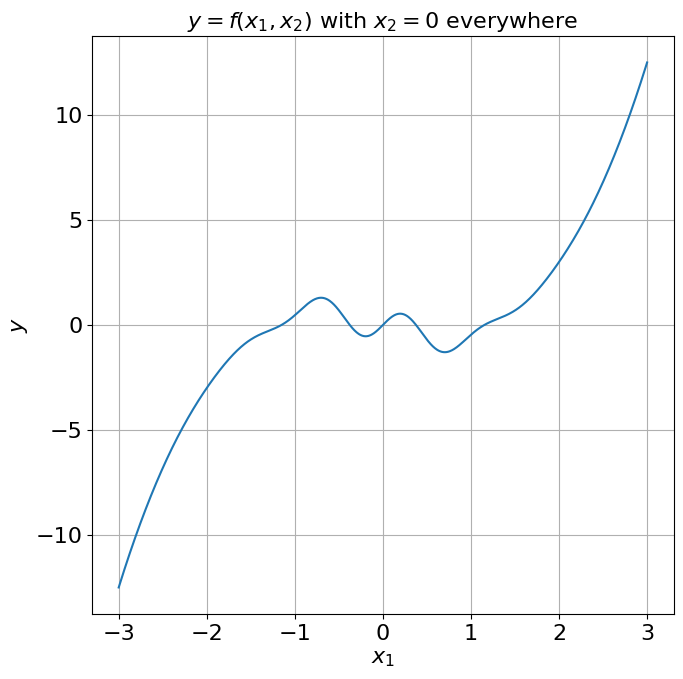

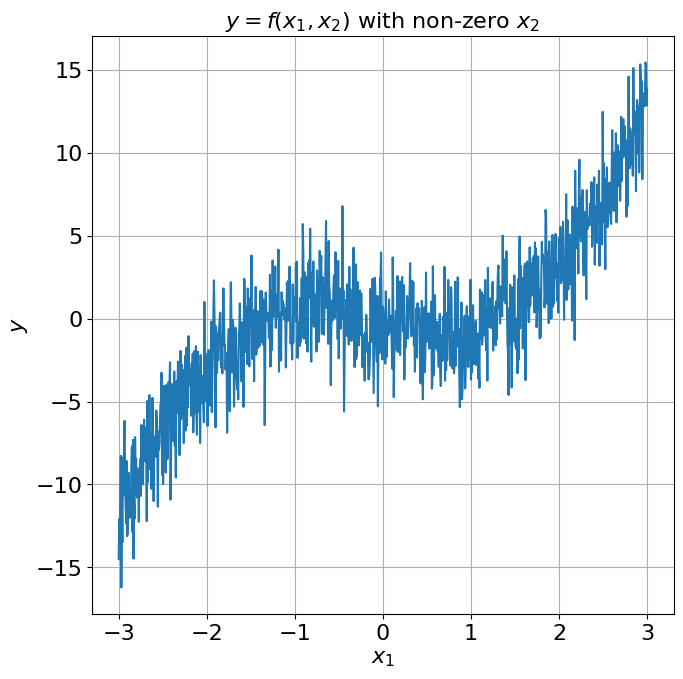

In [9]:
NUM_EXAMPLES = 1000

# Create a dataset with x_2 = 0 everywhere.
x1_values = numpy.linspace(-3, 3, num=NUM_EXAMPLES, dtype=float)
x2_values = numpy.full(NUM_EXAMPLES, 0.)
y_values = target_function_scenarios1and2(
    x1_values=x1_values, x2_values=x2_values
)

_, axes_object = pyplot.subplots(
    1, 1, figsize=(FIGURE_WIDTH_INCHES, FIGURE_HEIGHT_INCHES)
)
axes_object.plot(x1_values, y_values)
axes_object.set_xlabel(r'$x_1$')
axes_object.set_ylabel(r'$y$')
axes_object.set_title(r'$y = f(x_1, x_2)$ with $x_2 = 0$ everywhere')
axes_object.grid(True)

# Create a dataset with x_2 drawn from a standard normal distribution.
x2_values = numpy.random.normal(loc=0., scale=2., size=NUM_EXAMPLES)
y_values = target_function_scenarios1and2(
    x1_values=x1_values, x2_values=x2_values
)

_, axes_object = pyplot.subplots(
    1, 1, figsize=(FIGURE_WIDTH_INCHES, FIGURE_HEIGHT_INCHES)
)
axes_object.plot(x1_values, y_values)
axes_object.set_xlabel(r'$x_1$')
axes_object.set_ylabel(r'$y$')
axes_object.set_title(r'$y = f(x_1, x_2)$ with non-zero $x_2$')
axes_object.grid(True)

## Create the BNN/CRPS architecture

The next code cell creates a neural network with the BNN/CRPS architecture -- *i.e.*, using the hybrid BNN/CRPS method for uncertainty quantification.

In [10]:
model_object_scenario1 = create_bnn_crps_architecture(
    num_predictors=1,
    num_training_examples=10000,
    num_bayesian_layers=3,
    use_flipout=False
)
model_object_scenario1.summary()

/usr/local/lib/python3.11/dist-packages/tensorflow_probability/python/layers/util.py:98: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  loc = add_variable_fn(
/usr/local/lib/python3.11/dist-packages/tensorflow_probability/python/layers/util.py:108: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  untransformed_scale = add_variable_fn(


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 1)]               0         
                                                                 
 dense (Dense)               (None, 100)               200       
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 100)               0         
                                                                 
 batch_normalization (Batch  (None, 100)               400       
 Normalization)                                                  
                                                                 
 dense_1 (Dense)             (None, 100)               10100     
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 100)               0         
                                                             

## Train the model with one predictor (no $x_2$)

The next code cell trains a BNN/CRPS neural network to predict $y$ from $x_1$; the neural network uses only $x_1$ as a predictor, so crucial information from $x_2$ is not available.

In [11]:
NUM_EXAMPLES = 10000

x1_values = numpy.linspace(-3, 3, num=NUM_EXAMPLES, dtype=float)

training_x2_values = numpy.random.normal(loc=0., scale=2., size=NUM_EXAMPLES)
training_y_values = target_function_scenarios1and2(
    x1_values=x1_values, x2_values=training_x2_values
)
training_predictor_matrix = numpy.transpose(
    numpy.vstack([x1_values, training_x2_values])
)
training_target_matrix = numpy.expand_dims(training_y_values, axis=-1)

validation_x2_values = numpy.random.normal(loc=0., scale=2., size=NUM_EXAMPLES)
validation_y_values = target_function_scenarios1and2(
    x1_values=x1_values, x2_values=validation_x2_values
)
validation_predictor_matrix = numpy.transpose(
    numpy.vstack([x1_values, validation_x2_values])
)
validation_target_matrix = numpy.expand_dims(validation_y_values, axis=-1)

model_object = create_bnn_crps_architecture(
    num_predictors=1,
    num_training_examples=NUM_EXAMPLES,
    num_bayesian_layers=3,
    use_flipout=False
)
model_object.summary()

model_object.fit(
    x=training_predictor_matrix[:, :1],
    y=training_target_matrix,
    batch_size=100,
    epochs=100,
    initial_epoch=0,
    steps_per_epoch=100,
    shuffle=True,
    verbose=1,
    validation_data=(
        validation_predictor_matrix[:, :1], validation_target_matrix
    ),
    validation_steps=100
)

/usr/local/lib/python3.11/dist-packages/tensorflow_probability/python/layers/util.py:98: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  loc = add_variable_fn(
/usr/local/lib/python3.11/dist-packages/tensorflow_probability/python/layers/util.py:108: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  untransformed_scale = add_variable_fn(


Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 1)]               0         
                                                                 
 dense_2 (Dense)             (None, 100)               200       
                                                                 
 leaky_re_lu_4 (LeakyReLU)   (None, 100)               0         
                                                                 
 batch_normalization_4 (Bat  (None, 100)               400       
 chNormalization)                                                
                                                                 
 dense_3 (Dense)             (None, 100)               10100     
                                                                 
 leaky_re_lu_5 (LeakyReLU)   (None, 100)               0         
                                                           

## Evaluate the model on validation data (target values depending on $x_2$)

The next code cell evaluates the BNN/CRPS neural network on a validation set, where $x_2$ is generally non-zero (corresponding to the second plot under the "Data exploration" section above).

As $\lvert x_2 \rvert$ increases, the model's error (RMSE of the ensemble mean) increases, but spread-skill ratio decreases.  In other words, as $\lvert x_2 \rvert$ increases, the model makes increasingly wrong predictions but with high confidence.  At a certain point (a certain value of $\lvert x_2 \rvert$, depending on the application), these highly confident wrong predictions would be considered **catastrophic errors**.

Shape of validation_prediction_matrix = (10000, 500)


(<Figure size 750x750 with 2 Axes>,
 <Axes: title={'center': '"Skill" (RMSE of ensemble mean) as a function of $x_2$'}, xlabel='$x_2$ value', ylabel='"Skill" (RMSE of ensemble mean)'>)

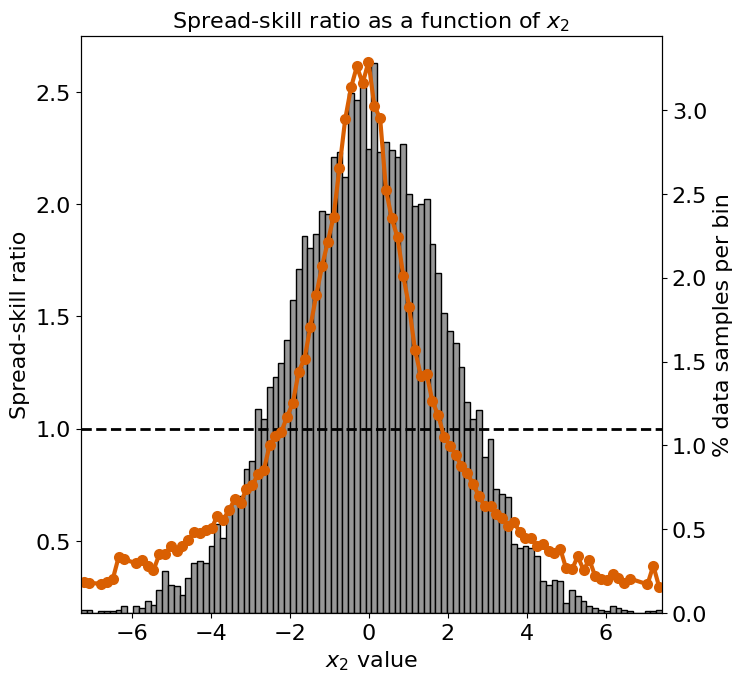

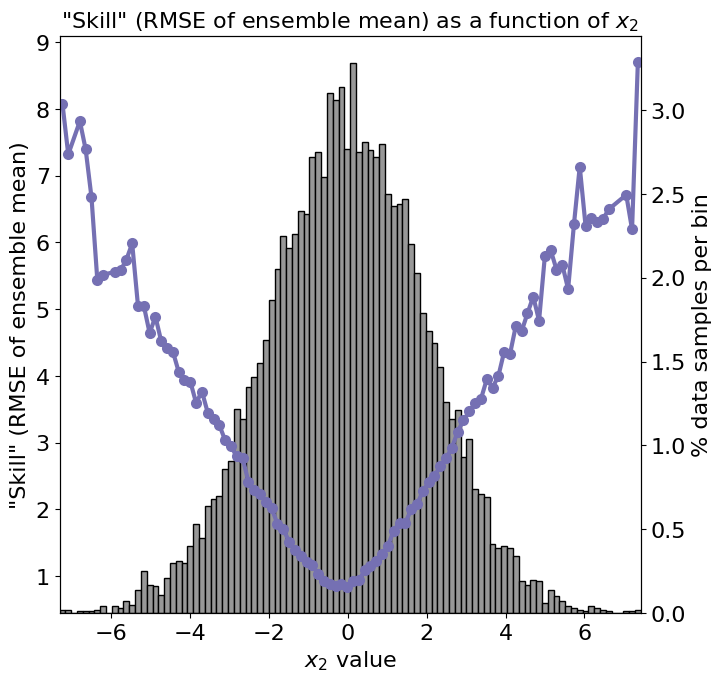

In [14]:
NUM_BINS = 100
NUM_ITERATIONS = 10

validation_prediction_matrix = numpy.array([])

for i in range(NUM_ITERATIONS):
    new_prediction_matrix = model_object.predict_on_batch(
        validation_predictor_matrix[:, :1]
    )

    if i == 0:
        validation_prediction_matrix = new_prediction_matrix + 0.
    else:
        validation_prediction_matrix = numpy.concatenate(
            [validation_prediction_matrix, new_prediction_matrix], axis=-1
        )

print('Shape of validation_prediction_matrix = {0:s}'.format(
    str(validation_prediction_matrix.shape)
))

validation_x2_values = validation_predictor_matrix[:, 1]
x2_bin_edges = numpy.linspace(
    numpy.min(validation_x2_values),
    numpy.max(validation_x2_values),
    num=NUM_BINS + 1, dtype=float
)

skill_by_bin = numpy.full(NUM_BINS, numpy.nan)
spread_by_bin = numpy.full(NUM_BINS, numpy.nan)
example_count_by_bin = numpy.full(NUM_BINS, 0, dtype=int)

for k in range(NUM_BINS):
    if k == NUM_BINS - 1:
        good_indices = numpy.where(validation_x2_values >= x2_bin_edges[k])[0]
    else:
        good_indices = numpy.where(numpy.logical_and(
            validation_x2_values >= x2_bin_edges[k],
            validation_x2_values < x2_bin_edges[k + 1]
        ))[0]

    example_count_by_bin[k] = len(good_indices)
    if example_count_by_bin[k] == 0:
        continue

    these_ensemble_means = numpy.mean(
        validation_prediction_matrix[good_indices, :], axis=-1
    )
    these_ensemble_stdevs = numpy.std(
        validation_prediction_matrix[good_indices, :], axis=-1, ddof=1
    )
    these_squared_errors = (
        these_ensemble_means - validation_target_matrix[good_indices, 0]
    ) ** 2

    skill_by_bin[k] = numpy.sqrt(numpy.mean(these_squared_errors))
    spread_by_bin[k] = numpy.sqrt(numpy.mean(these_ensemble_stdevs ** 2))

plot_skill_or_ssrat_versus_x2(
    skill_by_bin=skill_by_bin,
    spread_by_bin=spread_by_bin,
    example_count_by_bin=example_count_by_bin,
    x2_bin_edges=x2_bin_edges,
    plot_ssrat=True
)

plot_skill_or_ssrat_versus_x2(
    skill_by_bin=skill_by_bin,
    spread_by_bin=spread_by_bin,
    example_count_by_bin=example_count_by_bin,
    x2_bin_edges=x2_bin_edges,
    plot_ssrat=False
)

## Evaluate the model on dummy data (target values *not* depending on $x_2$)

The next code cell evaluates the BNN/CRPS neural network on a dummy validation set, where the target value $y_{\textrm{true}}$ does **not** depend on $x_2$.  Thus, instead of

$y_{\textrm{true}} = g(x_1) + x_2$,

the true target function is

$y_{\textrm{true}} = g(x_1)$.
<br />
<br />
In this case, both the true function and our neural-network-estimated function depend only on $x_1$.  Thus, our neural network is perfectly equipped to handle this dummy dataset and performs quite well.  Thus, we can conclude that the poor performance on the *real* validation set (above) is caused by the non-zero $x_2$-values in the real validation set.

Shape of testing_prediction_matrix = (10000, 500)


(<Figure size 750x750 with 2 Axes>,
 <Axes: title={'center': '"Skill" (RMSE of ensemble mean) as a function of $x_2$'}, xlabel='$x_2$ value', ylabel='"Skill" (RMSE of ensemble mean)'>)

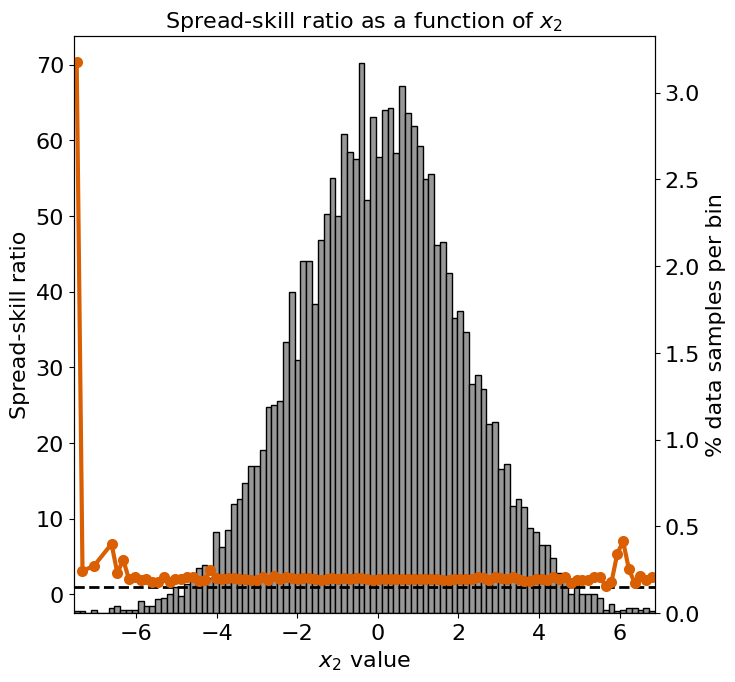

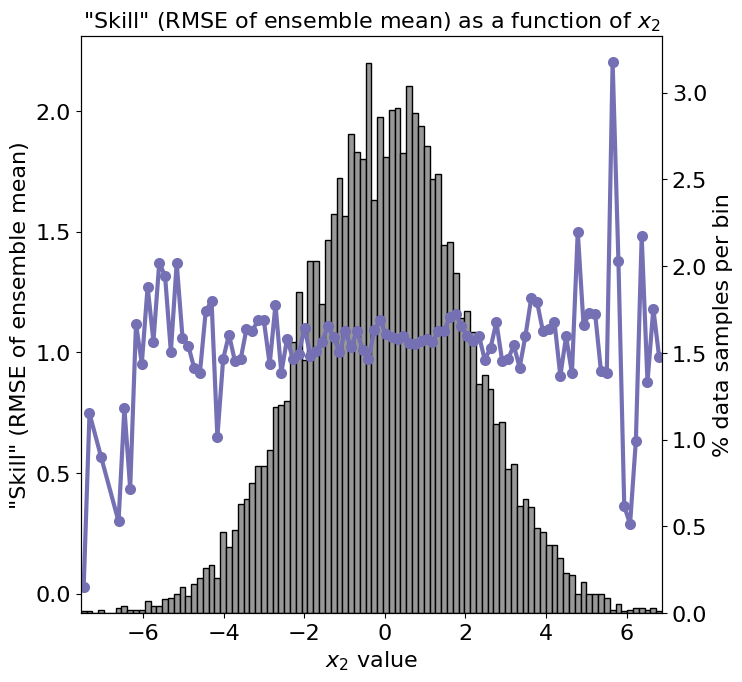

In [15]:
dummy_x2_values = numpy.random.normal(loc=0., scale=2., size=NUM_EXAMPLES)
dummy_y_values = target_function_scenarios1and2(
    x1_values=x1_values, x2_values=numpy.zeros_like(x1_values)
)
dummy_predictor_matrix = numpy.transpose(
    numpy.vstack([x1_values, dummy_x2_values])
)
dummy_target_matrix = numpy.expand_dims(dummy_y_values, axis=-1)

dummy_prediction_matrix = numpy.array([])

for i in range(NUM_ITERATIONS):
    new_prediction_matrix = model_object.predict_on_batch(
        dummy_predictor_matrix[:, :1]
    )

    if i == 0:
        dummy_prediction_matrix = new_prediction_matrix + 0.
    else:
        dummy_prediction_matrix = numpy.concatenate(
            [dummy_prediction_matrix, new_prediction_matrix], axis=-1
        )

print('Shape of dummy_prediction_matrix = {0:s}'.format(
    str(dummy_prediction_matrix.shape)
))

dummy_x2_values = dummy_predictor_matrix[:, 1]
x2_bin_edges = numpy.linspace(
    numpy.min(dummy_x2_values),
    numpy.max(dummy_x2_values),
    num=NUM_BINS + 1, dtype=float
)

skill_by_bin = numpy.full(NUM_BINS, numpy.nan)
spread_by_bin = numpy.full(NUM_BINS, numpy.nan)
example_count_by_bin = numpy.full(NUM_BINS, 0, dtype=int)

for k in range(NUM_BINS):
    if k == NUM_BINS - 1:
        good_indices = numpy.where(dummy_x2_values >= x2_bin_edges[k])[0]
    else:
        good_indices = numpy.where(numpy.logical_and(
            dummy_x2_values >= x2_bin_edges[k],
            dummy_x2_values < x2_bin_edges[k + 1]
        ))[0]

    example_count_by_bin[k] = len(good_indices)
    if example_count_by_bin[k] == 0:
        continue

    these_ensemble_means = numpy.mean(
        dummy_prediction_matrix[good_indices, :], axis=-1
    )
    these_ensemble_stdevs = numpy.std(
        dummy_prediction_matrix[good_indices, :], axis=-1, ddof=1
    )
    these_squared_errors = (
        these_ensemble_means - dummy_target_matrix[good_indices, 0]
    ) ** 2

    skill_by_bin[k] = numpy.sqrt(numpy.mean(these_squared_errors))
    spread_by_bin[k] = numpy.sqrt(numpy.mean(these_ensemble_stdevs ** 2))

plot_skill_or_ssrat_versus_x2(
    skill_by_bin=skill_by_bin,
    spread_by_bin=spread_by_bin,
    example_count_by_bin=example_count_by_bin,
    x2_bin_edges=x2_bin_edges,
    plot_ssrat=True
)

plot_skill_or_ssrat_versus_x2(
    skill_by_bin=skill_by_bin,
    spread_by_bin=spread_by_bin,
    example_count_by_bin=example_count_by_bin,
    x2_bin_edges=x2_bin_edges,
    plot_ssrat=False
)

# Scenario 2: Variable constant in training data

In this scenario, the target value is still a function of both $x_1$ and $x_2$ -- and appropriately, the model uses both $x_1$ and $x_2$ as predictors.
<br />
$y_{\textrm{true}} = f(x_1, x_2)$
<br />
$\vec{y}_{\textrm{pred}} = \hat{f}(x_1, x_2)$
<br />
<br />
However, $x_2 = 0$ everywhere in the training data.  Because $x_2$ has no variability in the training data, the model cannot learn any relationships involving $x_2$, so effectively:
<br />
$\vec{y}_{\textrm{pred}} = \hat{f}(x_1)$
<br />
<br />
In other words, scenario 2 is effectively the same as scenario 1 (where $x_2$ was not included in the predictors).  In both scenarios, any uncertainty caused by $x_2$ is unresolvable.

## Data exploration

As in scenario 1:
<br />
$y_{\textrm{true}} = g(x_1) + x_2$
<br />
$g = \textrm{sin}(2 \pi x_1) \textrm{ exp}(-x_1^2) + \frac{x_1^3}{2} - \textrm{tanh}(2x_1)$
<br />
<br />
The next code cell shows the relationship between $y_{\textrm{true}}$ and $x_1$ under two scenarios:
 - When $x_2 = 5$ everywhere
 - When $x_2$ is drawn from a normal distribution centered on 5

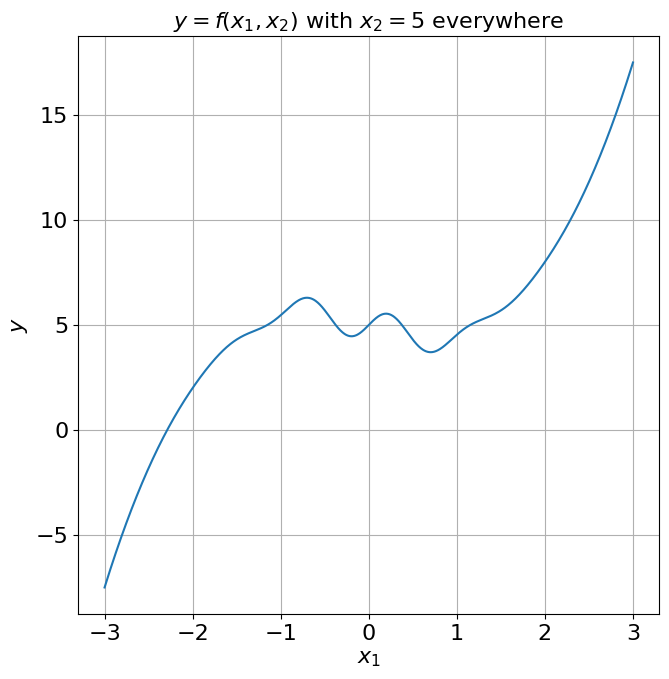

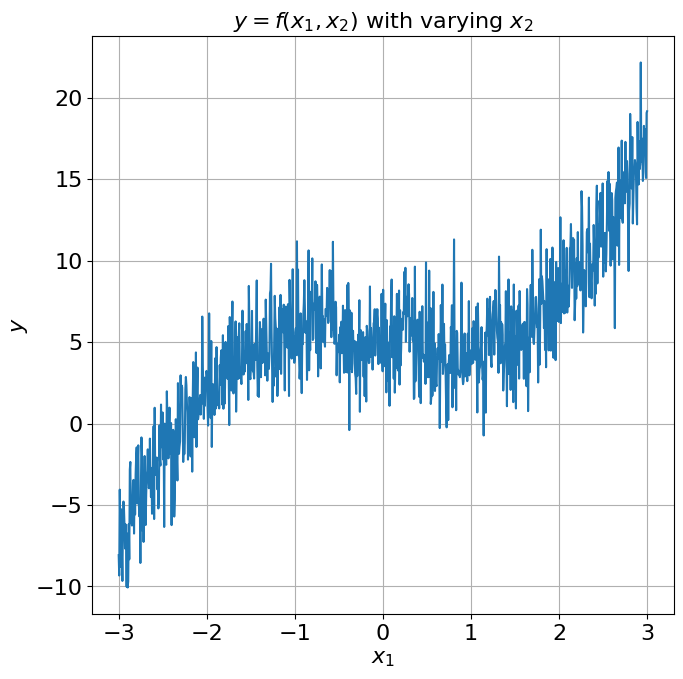

In [17]:
NUM_EXAMPLES = 1000

# Create a dataset with x_2 = 5 everywhere.
x1_values = numpy.linspace(-3, 3, num=NUM_EXAMPLES, dtype=float)
x2_values = numpy.full(NUM_EXAMPLES, 5.)
y_values = target_function_scenarios1and2(
    x1_values=x1_values, x2_values=x2_values
)

_, axes_object = pyplot.subplots(
    1, 1, figsize=(FIGURE_WIDTH_INCHES, FIGURE_HEIGHT_INCHES)
)
axes_object.plot(x1_values, y_values)
axes_object.set_xlabel(r'$x_1$')
axes_object.set_ylabel(r'$y$')
axes_object.set_title(r'$y = f(x_1, x_2)$ with $x_2 = 5$ everywhere')
axes_object.grid(True)

# Create a dataset with x_2 drawn from a normal distribution centered on 5.
x2_values = numpy.random.normal(loc=5., scale=2., size=NUM_EXAMPLES)
y_values = target_function_scenarios1and2(
    x1_values=x1_values, x2_values=x2_values
)

_, axes_object = pyplot.subplots(
    1, 1, figsize=(FIGURE_WIDTH_INCHES, FIGURE_HEIGHT_INCHES)
)
axes_object.plot(x1_values, y_values)
axes_object.set_xlabel(r'$x_1$')
axes_object.set_ylabel(r'$y$')
axes_object.set_title(r'$y = f(x_1, x_2)$ with varying $x_2$')
axes_object.grid(True)

## Train the model with both predictors (but $x_2 = 5$ for all training data)

The next code cell trains a BNN/CRPS neural network to predict $y$ from $x_1$ and $x_2$; the neural network uses both $x_1$ and $x_2$ as predictors, but $x_2 = 5$ everywhere in the training data, so the network has no opportunity to learn anything useful from $x_2$.

In [19]:
NUM_EXAMPLES = 10000

x1_values = numpy.linspace(-3, 3, num=NUM_EXAMPLES, dtype=float)

training_x2_values = numpy.full(NUM_EXAMPLES, 5.)
training_y_values = target_function_scenarios1and2(
    x1_values=x1_values, x2_values=training_x2_values
)
training_predictor_matrix = numpy.transpose(
    numpy.vstack([x1_values, training_x2_values])
)
training_target_matrix = numpy.expand_dims(training_y_values, axis=-1)

validation_x2_values = numpy.random.normal(loc=5., scale=2., size=NUM_EXAMPLES)
validation_y_values = target_function_scenarios1and2(
    x1_values=x1_values, x2_values=validation_x2_values
)
validation_predictor_matrix = numpy.transpose(
    numpy.vstack([x1_values, validation_x2_values])
)
validation_target_matrix = numpy.expand_dims(validation_y_values, axis=-1)

model_object = create_bnn_crps_architecture(
    num_predictors=2,
    num_training_examples=NUM_EXAMPLES,
    num_bayesian_layers=3,
    use_flipout=False
)
model_object.summary()

model_object.fit(
    x=training_predictor_matrix,
    y=training_target_matrix,
    batch_size=100,
    epochs=100,
    initial_epoch=0,
    steps_per_epoch=100,
    shuffle=True,
    verbose=1,
    validation_data=(validation_predictor_matrix, validation_target_matrix),
    validation_steps=100
)

/usr/local/lib/python3.11/dist-packages/tensorflow_probability/python/layers/util.py:98: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  loc = add_variable_fn(
/usr/local/lib/python3.11/dist-packages/tensorflow_probability/python/layers/util.py:108: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  untransformed_scale = add_variable_fn(


Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 2)]               0         
                                                                 
 dense_4 (Dense)             (None, 100)               300       
                                                                 
 leaky_re_lu_8 (LeakyReLU)   (None, 100)               0         
                                                                 
 batch_normalization_8 (Bat  (None, 100)               400       
 chNormalization)                                                
                                                                 
 dense_5 (Dense)             (None, 100)               10100     
                                                                 
 leaky_re_lu_9 (LeakyReLU)   (None, 100)               0         
                                                           

## Evaluate the model on validation data ($x_2 \neq 5$ generally)

The next code cell evaluates the BNN/CRPS neural network on a validation set, where $x_2$ is generally not 5 (corresponding to the second plot under the "Data exploration" section above).

As $\lvert x_2 - 5 \rvert$ increases, the model's error (RMSE of the ensemble mean) increases, but spread-skill ratio decreases.  In other words, as $\lvert x_2 - 5 \rvert$ increases, the model makes increasingly wrong predictions but with high confidence.  At a certain point (a certain value of $\lvert x_2 - 5 \rvert$, depending on the application), these highly confident wrong predictions would be considered **catastrophic errors**.

Shape of validation_prediction_matrix = (10000, 500)


(-1.5411090062222994, 57.44587891704825)

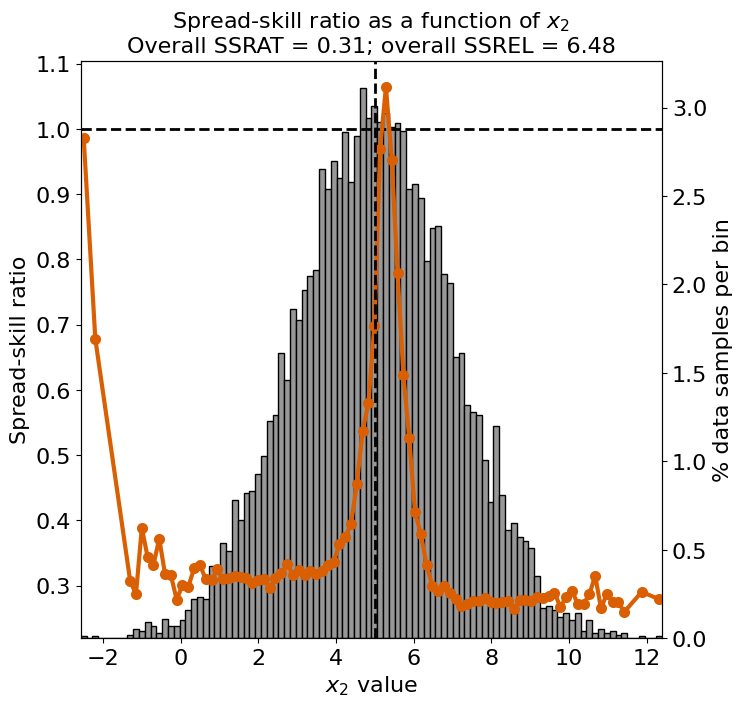

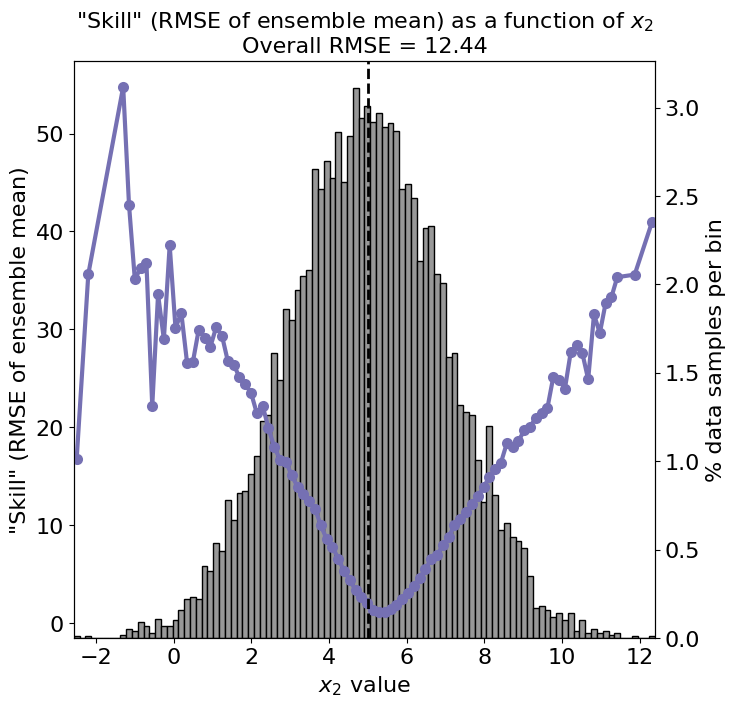

In [30]:
NUM_BINS = 100
NUM_ITERATIONS = 10

validation_prediction_matrix = numpy.array([])

for i in range(NUM_ITERATIONS):
    new_prediction_matrix = model_object.predict_on_batch(
        validation_predictor_matrix
    )

    if i == 0:
        validation_prediction_matrix = new_prediction_matrix + 0.
    else:
        validation_prediction_matrix = numpy.concatenate(
            [validation_prediction_matrix, new_prediction_matrix], axis=-1
        )

print('Shape of validation_prediction_matrix = {0:s}'.format(
    str(validation_prediction_matrix.shape)
))

validation_x2_values = validation_predictor_matrix[:, 1]
x2_bin_edges = numpy.linspace(
    numpy.min(validation_x2_values),
    numpy.max(validation_x2_values),
    num=NUM_BINS + 1, dtype=float
)

skill_by_bin = numpy.full(NUM_BINS, numpy.nan)
spread_by_bin = numpy.full(NUM_BINS, numpy.nan)
example_count_by_bin = numpy.full(NUM_BINS, 0, dtype=int)

for k in range(NUM_BINS):
    if k == NUM_BINS - 1:
        good_indices = numpy.where(validation_x2_values >= x2_bin_edges[k])[0]
    else:
        good_indices = numpy.where(numpy.logical_and(
            validation_x2_values >= x2_bin_edges[k],
            validation_x2_values < x2_bin_edges[k + 1]
        ))[0]

    example_count_by_bin[k] = len(good_indices)
    if example_count_by_bin[k] == 0:
        continue

    these_ensemble_means = numpy.mean(
        validation_prediction_matrix[good_indices, :], axis=-1
    )
    these_ensemble_stdevs = numpy.std(
        validation_prediction_matrix[good_indices, :], axis=-1, ddof=1
    )
    these_squared_errors = (
        these_ensemble_means - validation_target_matrix[good_indices, 0]
    ) ** 2

    skill_by_bin[k] = numpy.sqrt(numpy.mean(these_squared_errors))
    spread_by_bin[k] = numpy.sqrt(numpy.mean(these_ensemble_stdevs ** 2))

_, axes_object = plot_skill_or_ssrat_versus_x2(
    skill_by_bin=skill_by_bin,
    spread_by_bin=spread_by_bin,
    example_count_by_bin=example_count_by_bin,
    x2_bin_edges=x2_bin_edges,
    plot_ssrat=True
)
reference_x_coords = numpy.array([5., 5.])
reference_y_coords = axes_object.get_ylim()
axes_object.plot(
    reference_x_coords,
    reference_y_coords,
    color=numpy.full(3, 0.),
    linestyle='dashed',
    linewidth=REFERENCE_LINE_WIDTH
)
axes_object.set_ylim(reference_y_coords)

_, axes_object = plot_skill_or_ssrat_versus_x2(
    skill_by_bin=skill_by_bin,
    spread_by_bin=spread_by_bin,
    example_count_by_bin=example_count_by_bin,
    x2_bin_edges=x2_bin_edges,
    plot_ssrat=False
)
reference_x_coords = numpy.array([5., 5.])
reference_y_coords = axes_object.get_ylim()
axes_object.plot(
    reference_x_coords,
    reference_y_coords,
    color=numpy.full(3, 0.),
    linestyle='dashed',
    linewidth=REFERENCE_LINE_WIDTH
)
axes_object.set_ylim(reference_y_coords)

## Evaluate the model on dummy data ($x_2 = 5$ everywhere)

The next code cell evaluates the BNN/CRPS neural network on a dummy validation set, where $x_2 = 5$ everywhere.  Thus, the true target function can be written with $x_2$:

$y_{\textrm{true}} = g(x_1) + x_2$,

or without it:

$y_{\textrm{true}} = g(x_1) + 5$.
<br />
<br />
In this case, both the true function and our neural-network-estimated function depend only on $x_1$.  Thus, our neural network is perfectly equipped to handle this dummy dataset and performs much better (compare values of overall SSRAT, SSREL, and RMSE).  Thus, we can conclude that the poor performance on the *real* validation set (above) is caused by $x_2$ deviating from 5 in the real validation set.

Shape of testing_prediction_matrix = (10000, 500)


<ipython-input-36-80498b699ccb>:453: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  axes_object.set_xlim(x_min, x_max)


(1.8523638398685593, 2.067982911176011)

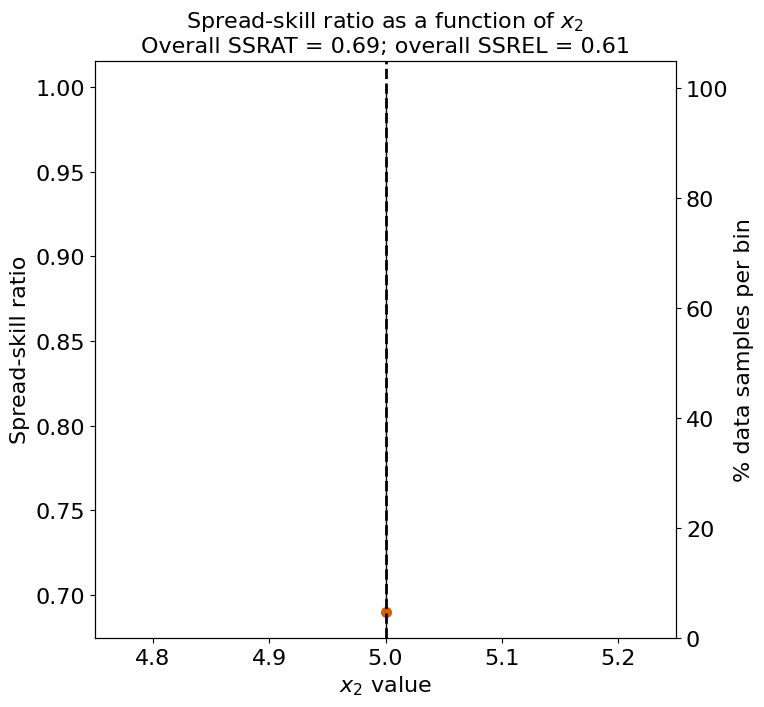

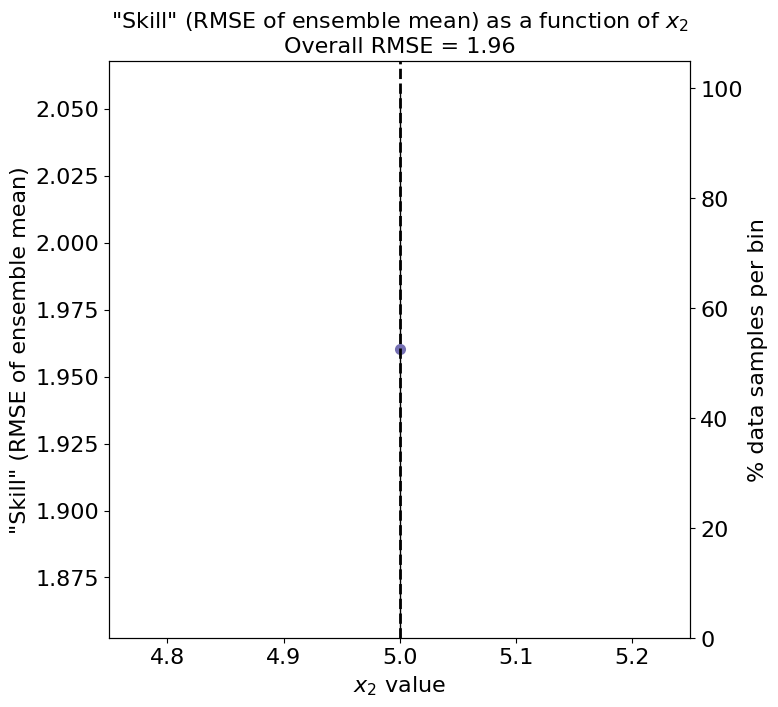

In [37]:
dummy_x2_values = numpy.full(NUM_EXAMPLES, 5.)
dummy_y_values = target_function_scenarios1and2(
    x1_values=x1_values, x2_values=dummy_x2_values
)
dummy_predictor_matrix = numpy.transpose(
    numpy.vstack([x1_values, dummy_x2_values])
)
dummy_target_matrix = numpy.expand_dims(dummy_y_values, axis=-1)

dummy_prediction_matrix = numpy.array([])

for i in range(NUM_ITERATIONS):
    new_prediction_matrix = model_object.predict_on_batch(
        dummy_predictor_matrix
    )

    if i == 0:
        dummy_prediction_matrix = new_prediction_matrix + 0.
    else:
        dummy_prediction_matrix = numpy.concatenate(
            [dummy_prediction_matrix, new_prediction_matrix], axis=-1
        )

print('Shape of dummy_prediction_matrix = {0:s}'.format(
    str(dummy_prediction_matrix.shape)
))

dummy_x2_values = dummy_predictor_matrix[:, 1]
x2_bin_edges = numpy.linspace(
    numpy.min(dummy_x2_values),
    numpy.max(dummy_x2_values),
    num=NUM_BINS + 1, dtype=float
)

skill_by_bin = numpy.full(NUM_BINS, numpy.nan)
spread_by_bin = numpy.full(NUM_BINS, numpy.nan)
example_count_by_bin = numpy.full(NUM_BINS, 0, dtype=int)

for k in range(NUM_BINS):
    if k == NUM_BINS - 1:
        good_indices = numpy.where(dummy_x2_values >= x2_bin_edges[k])[0]
    else:
        good_indices = numpy.where(numpy.logical_and(
            dummy_x2_values >= x2_bin_edges[k],
            dummy_x2_values < x2_bin_edges[k + 1]
        ))[0]

    example_count_by_bin[k] = len(good_indices)
    if example_count_by_bin[k] == 0:
        continue

    these_ensemble_means = numpy.mean(
        dummy_prediction_matrix[good_indices, :], axis=-1
    )
    these_ensemble_stdevs = numpy.std(
        dummy_prediction_matrix[good_indices, :], axis=-1, ddof=1
    )
    these_squared_errors = (
        these_ensemble_means - dummy_target_matrix[good_indices, 0]
    ) ** 2

    skill_by_bin[k] = numpy.sqrt(numpy.mean(these_squared_errors))
    spread_by_bin[k] = numpy.sqrt(numpy.mean(these_ensemble_stdevs ** 2))

_, axes_object = plot_skill_or_ssrat_versus_x2(
    skill_by_bin=skill_by_bin,
    spread_by_bin=spread_by_bin,
    example_count_by_bin=example_count_by_bin,
    x2_bin_edges=x2_bin_edges,
    plot_ssrat=True
)
reference_x_coords = numpy.array([5., 5.])
reference_y_coords = axes_object.get_ylim()
axes_object.plot(
    reference_x_coords,
    reference_y_coords,
    color=numpy.full(3, 0.),
    linestyle='dashed',
    linewidth=REFERENCE_LINE_WIDTH
)
axes_object.set_ylim(reference_y_coords)

_, axes_object = plot_skill_or_ssrat_versus_x2(
    skill_by_bin=skill_by_bin,
    spread_by_bin=spread_by_bin,
    example_count_by_bin=example_count_by_bin,
    x2_bin_edges=x2_bin_edges,
    plot_ssrat=False
)
reference_x_coords = numpy.array([5., 5.])
reference_y_coords = axes_object.get_ylim()
axes_object.plot(
    reference_x_coords,
    reference_y_coords,
    color=numpy.full(3, 0.),
    linestyle='dashed',
    linewidth=REFERENCE_LINE_WIDTH
)
axes_object.set_ylim(reference_y_coords)

# Scenario 3: Missing basis vector in training data

In this scenario, the target value is still a function of both $x_1$ and $x_2$ -- and appropriately, the model uses both $x_1$ and $x_2$ as predictors.
<br />
$y_{\textrm{true}} = f(x_1, x_2)$
<br />
$\vec{y}_{\textrm{pred}} = \hat{f}(x_1, x_2)$
<br />
<br />
The range of possible values for $x_1$ is $-7\ldots+7$; the range of possible values for $x_2$ is also $-7\ldots+7$.  In the model's training set, both $x_1$ and $x_2$ span the full range of possible values -- so we should be good, right?
<br />
<br />
Wrong!  Even though the training dataset spans the full *univariate* space for each predictor, it does not span the full *multivariate* space.  Specifically, the training dataset contains no examples with $x_1 + x_2 > 7$ or $x_1 + x_2 < -7$, even though the range of possible values for $x_1 + x_2$ is $-14\ldots+14$.  In other words, the training dataset does not sample adequately along the **basis vector** $x_1 + x_2$.  At inference time, when we encounter a training sample with $x_1 + x_2 \approxeq -14$ or $x_1 + x_2 \approxeq 14$, it will be far **out-of-sample** with respect to the training data, even if both the individual variables are in sample.

## Data exploration

Specifically, $y_{\textrm{true}} = A(x_1, x_2) b(x_1, x_2)$, where $A$ is the amplitude-envelope function and $b$ is the base function.

$b = \textrm{sin}(3x_1) \textrm{cos}(3x_2) + 0.2\textrm{sin}(5 x_1 x_2)$
<br />
$A = 1 + \frac{x_1^2 + x_2^2}{2}$
<br />
<br />
The next code cell shows the above relationship under two scenarios:
 - When $x_1 + x_2$ covers the full range of possible values ($-14\ldots+14$)
 - When $x_1 + x_2$ is limited to $-7\ldots+7$

<ipython-input-99-8119cf66d489>:26: UserWarning: The following kwargs were not used by contour: 'linestyle', 'linewidth'
  contour_handle = axes_object.contour(
<ipython-input-99-8119cf66d489>:79: UserWarning: The following kwargs were not used by contour: 'linestyle', 'linewidth'
  contour_handle = axes_object.contour(


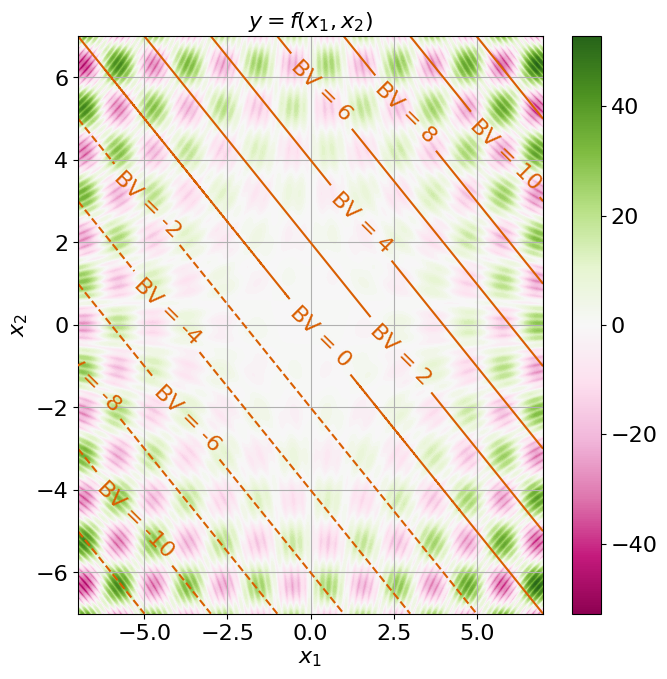

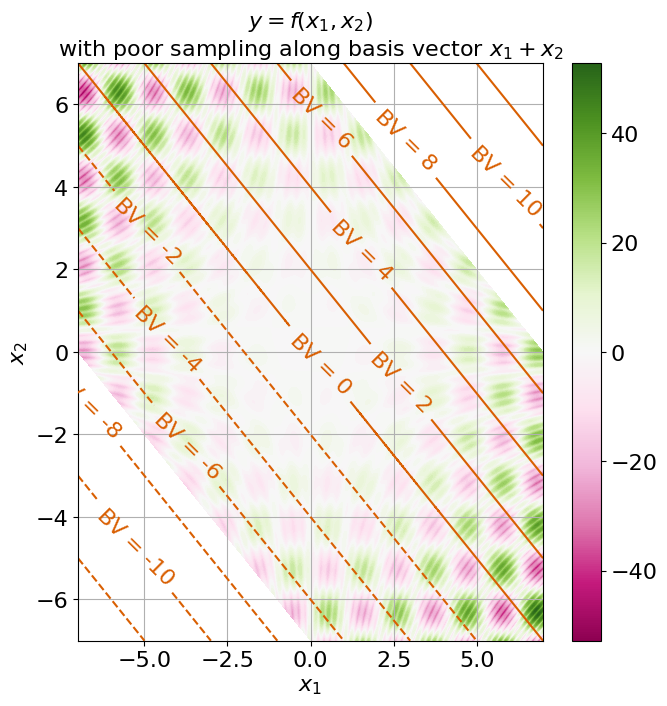

In [99]:
NUM_EXAMPLES_PER_AXIS = 1000
BASIS_VECTOR_COLOUR = numpy.array([217, 95, 2], dtype=float) / 255

# Create a dataset with both x_1 and x_2 varying from -5...5.
unique_x1_values = numpy.linspace(-7, 7, num=NUM_EXAMPLES_PER_AXIS, dtype=float)
unique_x2_values = numpy.linspace(-7, 7, num=NUM_EXAMPLES_PER_AXIS, dtype=float)
x1_matrix, x2_matrix = numpy.meshgrid(unique_x1_values, unique_x2_values)
y_matrix = target_function_scenario3(x1_values=x1_matrix, x2_values=x2_matrix)
basis_vector_matrix = x1_matrix + x2_matrix

_, axes_object = pyplot.subplots(
    1, 1, figsize=(FIGURE_WIDTH_INCHES, FIGURE_HEIGHT_INCHES)
)

colour_map_object = pyplot.get_cmap('PiYG')
colour_norm_object = pyplot.Normalize(
    vmin=-1 * numpy.max(numpy.absolute(y_matrix)),
    vmax=numpy.max(numpy.absolute(y_matrix))
)
axes_object.contourf(
    x1_matrix, x2_matrix, y_matrix,
    levels=100,
    cmap=colour_map_object,
    norm=colour_norm_object
)
contour_handle = axes_object.contour(
    x1_matrix, x2_matrix, basis_vector_matrix,
    levels=numpy.linspace(-14, 14, num=15, dtype=float),
    colors=BASIS_VECTOR_COLOUR,
    linestyle='solid',
    linewidth=2
)
axes_object.clabel(
    contour_handle,
    inline=True,
    fontsize=16,
    colors=tuple([BASIS_VECTOR_COLOUR] * 15),
    fmt=lambda val: f'BV = {val:.0f}',
    inline_spacing=15
)

axes_object.set_xlabel(r'$x_1$')
axes_object.set_ylabel(r'$x_2$')
axes_object.set_title(r'$y = f(x_1, x_2)$')
axes_object.grid(True)

plot_colour_bar(
    axes_object_or_matrix=axes_object,
    data_matrix=y_matrix,
    colour_map_object=colour_map_object,
    colour_norm_object=colour_norm_object,
    orientation_string='vertical',
    extend_min=False,
    extend_max=False
)

# Create a similar dataset but with poor sampling along the basis vector
# x_1 + x_2.
y_matrix[x1_matrix + x2_matrix > 7] = numpy.nan
y_matrix[x1_matrix + x2_matrix < -7] = numpy.nan
y_matrix = numpy.ma.masked_where(numpy.isnan(y_matrix), y_matrix)

_, axes_object = pyplot.subplots(
    1, 1, figsize=(FIGURE_WIDTH_INCHES, FIGURE_HEIGHT_INCHES)
)

colour_map_object = pyplot.get_cmap('PiYG').copy()
colour_map_object.set_bad(numpy.full(3, 152. / 255))
colour_norm_object = pyplot.Normalize(
    vmin=-1 * numpy.nanmax(numpy.absolute(y_matrix)),
    vmax=numpy.nanmax(numpy.absolute(y_matrix))
)
axes_object.contourf(
    x1_matrix, x2_matrix, y_matrix,
    levels=100,
    cmap=colour_map_object,
    norm=colour_norm_object
)
contour_handle = axes_object.contour(
    x1_matrix, x2_matrix, basis_vector_matrix,
    levels=numpy.linspace(-14, 14, num=15, dtype=float),
    colors=BASIS_VECTOR_COLOUR,
    linestyle='solid',
    linewidth=2
)
axes_object.clabel(
    contour_handle,
    inline=True,
    fontsize=16,
    colors=tuple([BASIS_VECTOR_COLOUR] * 15),
    fmt=lambda val: f'BV = {val:.0f}',
    inline_spacing=15
)

axes_object.set_xlabel(r'$x_1$')
axes_object.set_ylabel(r'$x_2$')
axes_object.set_title(
    r'$y = f(x_1, x_2)$' + '\n' +
    r'with poor sampling along basis vector $x_1 + x_2$'
)
axes_object.grid(True)

plot_colour_bar(
    axes_object_or_matrix=axes_object,
    data_matrix=y_matrix,
    colour_map_object=colour_map_object,
    colour_norm_object=colour_norm_object,
    orientation_string='vertical',
    extend_min=False,
    extend_max=False
)

## Train the model with poorly sampled basis vector

The next code cell trains a BNN/CRPS neural network to predict $y$ from $x_1$ and $x_2$; the neural network uses both $x_1$ and $x_2$ as predictors, but $\lvert x_1 + x_2 \rvert < 7$ everywhere in the training data, so the network has no opportunity to learn what happens when $\lvert x_1 + x_2 \rvert \in \left[ 7, 14 \right]$.

In [100]:
NUM_EXAMPLES_PER_AXIS = 500

unique_x1_values = numpy.linspace(-7, 7, num=NUM_EXAMPLES_PER_AXIS, dtype=float)
unique_x2_values = numpy.linspace(-7, 7, num=NUM_EXAMPLES_PER_AXIS, dtype=float)
x1_matrix, x2_matrix = numpy.meshgrid(unique_x1_values, unique_x2_values)

all_x1_values = numpy.ravel(x1_matrix)
all_x2_values = numpy.ravel(x2_matrix)
all_y_values = target_function_scenario3(
    x1_values=all_x1_values, x2_values=all_x2_values
)

first_bad_flags = all_x1_values + all_x2_values > 7
second_bad_flags = all_x1_values + all_x2_values < -7
training_indices = numpy.where(
    numpy.invert(numpy.logical_or(first_bad_flags, second_bad_flags))
)[0]

training_x1_values = all_x1_values[training_indices]
training_x2_values = all_x2_values[training_indices]
training_y_values = all_y_values[training_indices]
training_predictor_matrix = numpy.transpose(
    numpy.vstack([training_x1_values, training_x2_values])
)
training_target_matrix = numpy.expand_dims(training_y_values, axis=-1)

validation_predictor_matrix = numpy.transpose(
    numpy.vstack([all_x1_values, all_x2_values])
)
validation_target_matrix = numpy.expand_dims(all_y_values, axis=-1)

model_object = create_bnn_crps_architecture(
    num_predictors=2,
    num_training_examples=training_predictor_matrix.shape[0],
    num_bayesian_layers=3,
    use_flipout=False
)
model_object.summary()

model_object.fit(
    x=training_predictor_matrix,
    y=training_target_matrix,
    batch_size=int(numpy.round(
        float(training_predictor_matrix.shape[0]) / 100
    )),
    epochs=25,
    initial_epoch=0,
    steps_per_epoch=100,
    shuffle=True,
    verbose=1,
    validation_data=(validation_predictor_matrix, validation_target_matrix),
    validation_steps=100
)

/usr/local/lib/python3.11/dist-packages/tensorflow_probability/python/layers/util.py:98: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  loc = add_variable_fn(
/usr/local/lib/python3.11/dist-packages/tensorflow_probability/python/layers/util.py:108: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  untransformed_scale = add_variable_fn(


Model: "model_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_12 (InputLayer)       [(None, 2)]               0         
                                                                 
 dense_22 (Dense)            (None, 100)               300       
                                                                 
 leaky_re_lu_44 (LeakyReLU)  (None, 100)               0         
                                                                 
 batch_normalization_44 (Ba  (None, 100)               400       
 tchNormalization)                                               
                                                                 
 dense_23 (Dense)            (None, 100)               10100     
                                                                 
 leaky_re_lu_45 (LeakyReLU)  (None, 100)               0         
                                                          

## Evaluate the model on validation data (basis vector spans full range)

The next code cell evaluates the BNN/CRPS neural network on a validation set, where $\lvert x_1 + x_2 \rvert$ ranges all the way up to 14.

As $\lvert x_1 + x_2 \rvert$ increases beyond 7, the model's error (RMSE of the ensemble mean) increases, but spread-skill ratio decreases.  In other words, the model makes increasingly wrong predictions but with high confidence.  At a certain point (a certain distance of $\lvert x_1 + x_2 \rvert$ away from 7, depending on the application), these highly confident wrong predictions would be considered **catastrophic errors**.

Shape of validation_prediction_matrix = (250000, 500)


(<Figure size 750x750 with 2 Axes>,
 <Axes: title={'center': '"Skill" (RMSE of ensemble mean) as a function of basis vector $x_1 + x_2$\nOverall RMSE = 25.12'}, xlabel='Value of basis vector = $x_1 + x_2$', ylabel='"Skill" (RMSE of ensemble mean)'>)

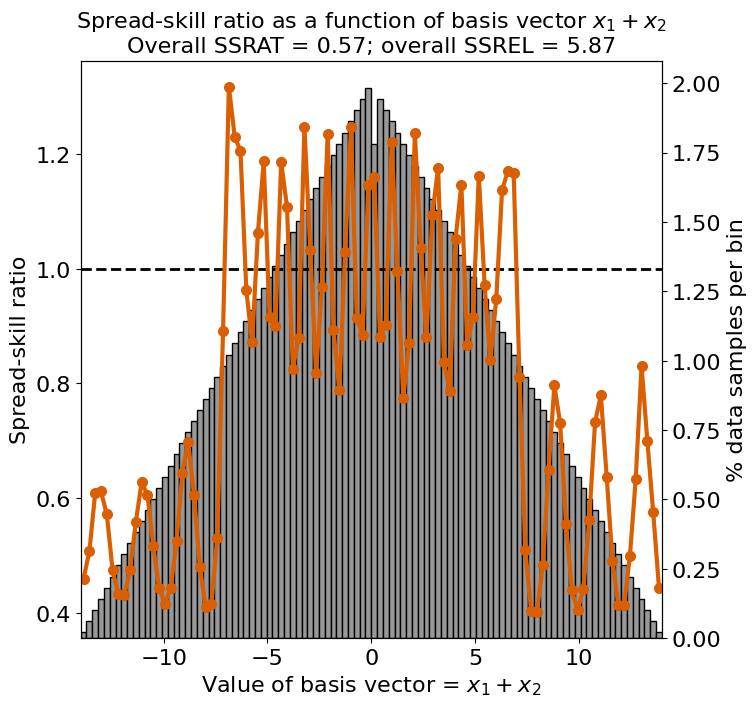

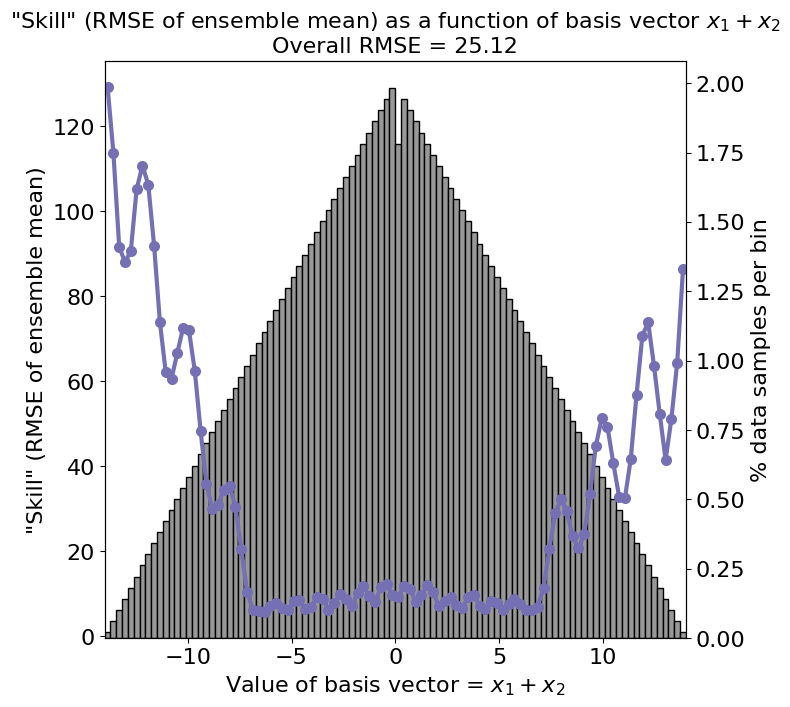

In [102]:
NUM_BINS = 100
NUM_ITERATIONS = 10

validation_prediction_matrix = numpy.array([])

for i in range(NUM_ITERATIONS):
    new_prediction_matrix = model_object.predict_on_batch(
        validation_predictor_matrix
    )

    if i == 0:
        validation_prediction_matrix = new_prediction_matrix + 0.
    else:
        validation_prediction_matrix = numpy.concatenate(
            [validation_prediction_matrix, new_prediction_matrix], axis=-1
        )

print('Shape of validation_prediction_matrix = {0:s}'.format(
    str(validation_prediction_matrix.shape)
))

validation_bv_values = (
    validation_predictor_matrix[:, 0] + validation_predictor_matrix[:, 1]
)
bv_bin_edges = numpy.linspace(
    numpy.min(validation_bv_values),
    numpy.max(validation_bv_values),
    num=NUM_BINS + 1, dtype=float
)

skill_by_bin = numpy.full(NUM_BINS, numpy.nan)
spread_by_bin = numpy.full(NUM_BINS, numpy.nan)
example_count_by_bin = numpy.full(NUM_BINS, 0, dtype=int)

for k in range(NUM_BINS):
    if k == NUM_BINS - 1:
        good_indices = numpy.where(validation_bv_values >= bv_bin_edges[k])[0]
    else:
        good_indices = numpy.where(numpy.logical_and(
            validation_bv_values >= bv_bin_edges[k],
            validation_bv_values < bv_bin_edges[k + 1]
        ))[0]

    example_count_by_bin[k] = len(good_indices)
    if example_count_by_bin[k] == 0:
        continue

    these_ensemble_means = numpy.mean(
        validation_prediction_matrix[good_indices, :], axis=-1
    )
    these_ensemble_stdevs = numpy.std(
        validation_prediction_matrix[good_indices, :], axis=-1, ddof=1
    )
    these_squared_errors = (
        these_ensemble_means - validation_target_matrix[good_indices, 0]
    ) ** 2

    skill_by_bin[k] = numpy.sqrt(numpy.mean(these_squared_errors))
    spread_by_bin[k] = numpy.sqrt(numpy.mean(these_ensemble_stdevs ** 2))

plot_skill_or_ssrat_versus_bv(
    skill_by_bin=skill_by_bin,
    spread_by_bin=spread_by_bin,
    example_count_by_bin=example_count_by_bin,
    basis_vector_bin_edges=bv_bin_edges,
    plot_ssrat=True
)

plot_skill_or_ssrat_versus_bv(
    skill_by_bin=skill_by_bin,
    spread_by_bin=spread_by_bin,
    example_count_by_bin=example_count_by_bin,
    basis_vector_bin_edges=bv_bin_edges,
    plot_ssrat=False
)

## Evaluate the model on dummy data (poorly sampled basis vector again)

The next code cell evaluates the BNN/CRPS neural network on a dummy validation set, where $\lvert x_1 + x_2 \rvert < 7$ everywhere.
<br />
<br />
In this case, both the true function and our neural-network-estimated function are not affected by $\lvert x_1 + x_2 \rvert$ values above 7.  Thus, our neural network is perfectly equipped to handle this dummy dataset and performs much better (compare values of overall SSRAT, SSREL, and RMSE).  Thus, we can conclude that the poor performance on the *real* validation set (above) is caused by $\lvert x_1 + x_2 \rvert$ exceeding 7 in the real validation set.

Shape of testing_prediction_matrix = (250000, 500)


(<Figure size 750x750 with 2 Axes>,
 <Axes: title={'center': '"Skill" (RMSE of ensemble mean) as a function of basis vector $x_1 + x_2$\nOverall RMSE = 2.76'}, xlabel='Value of basis vector = $x_1 + x_2$', ylabel='"Skill" (RMSE of ensemble mean)'>)

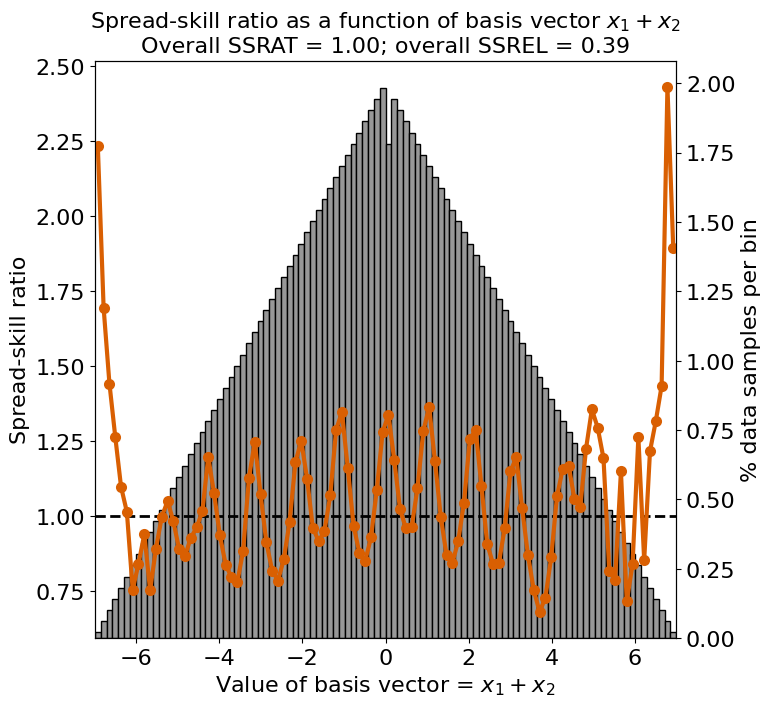

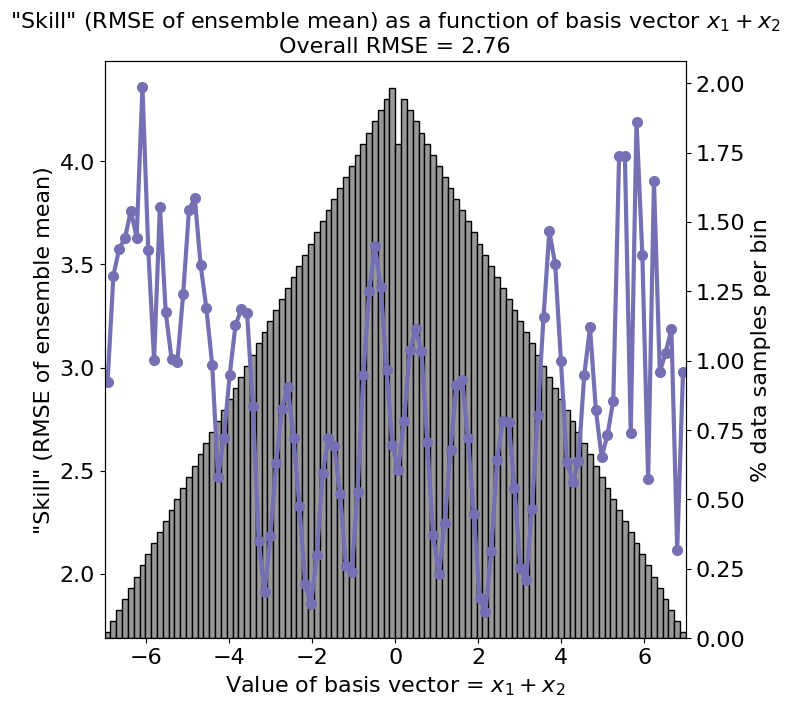

In [103]:
NUM_EXAMPLES_PER_AXIS = 500

unique_x1_values = numpy.linspace(-3.5, 3.5, num=NUM_EXAMPLES_PER_AXIS, dtype=float)
unique_x2_values = numpy.linspace(-3.5, 3.5, num=NUM_EXAMPLES_PER_AXIS, dtype=float)
x1_matrix, x2_matrix = numpy.meshgrid(unique_x1_values, unique_x2_values)

all_x1_values = numpy.ravel(x1_matrix)
all_x2_values = numpy.ravel(x2_matrix)
all_y_values = target_function_scenario3(
    x1_values=all_x1_values, x2_values=all_x2_values
)

dummy_predictor_matrix = numpy.transpose(
    numpy.vstack([all_x1_values, all_x2_values])
)
dummy_target_matrix = numpy.expand_dims(all_y_values, axis=-1)

NUM_BINS = 100
NUM_ITERATIONS = 10

dummy_prediction_matrix = numpy.array([])

for i in range(NUM_ITERATIONS):
    new_prediction_matrix = model_object.predict_on_batch(
        dummy_predictor_matrix
    )

    if i == 0:
        dummy_prediction_matrix = new_prediction_matrix + 0.
    else:
        dummy_prediction_matrix = numpy.concatenate(
            [dummy_prediction_matrix, new_prediction_matrix], axis=-1
        )

print('Shape of dummy_prediction_matrix = {0:s}'.format(
    str(dummy_prediction_matrix.shape)
))

dummy_bv_values = (
    dummy_predictor_matrix[:, 0] + dummy_predictor_matrix[:, 1]
)
bv_bin_edges = numpy.linspace(
    numpy.min(dummy_bv_values),
    numpy.max(dummy_bv_values),
    num=NUM_BINS + 1, dtype=float
)

skill_by_bin = numpy.full(NUM_BINS, numpy.nan)
spread_by_bin = numpy.full(NUM_BINS, numpy.nan)
example_count_by_bin = numpy.full(NUM_BINS, 0, dtype=int)

for k in range(NUM_BINS):
    if k == NUM_BINS - 1:
        good_indices = numpy.where(dummy_bv_values >= bv_bin_edges[k])[0]
    else:
        good_indices = numpy.where(numpy.logical_and(
            dummy_bv_values >= bv_bin_edges[k],
            dummy_bv_values < bv_bin_edges[k + 1]
        ))[0]

    example_count_by_bin[k] = len(good_indices)
    if example_count_by_bin[k] == 0:
        continue

    these_ensemble_means = numpy.mean(
        dummy_prediction_matrix[good_indices, :], axis=-1
    )
    these_ensemble_stdevs = numpy.std(
        dummy_prediction_matrix[good_indices, :], axis=-1, ddof=1
    )
    these_squared_errors = (
        these_ensemble_means - dummy_target_matrix[good_indices, 0]
    ) ** 2

    skill_by_bin[k] = numpy.sqrt(numpy.mean(these_squared_errors))
    spread_by_bin[k] = numpy.sqrt(numpy.mean(these_ensemble_stdevs ** 2))

plot_skill_or_ssrat_versus_bv(
    skill_by_bin=skill_by_bin,
    spread_by_bin=spread_by_bin,
    example_count_by_bin=example_count_by_bin,
    basis_vector_bin_edges=bv_bin_edges,
    plot_ssrat=True
)

plot_skill_or_ssrat_versus_bv(
    skill_by_bin=skill_by_bin,
    spread_by_bin=spread_by_bin,
    example_count_by_bin=example_count_by_bin,
    basis_vector_bin_edges=bv_bin_edges,
    plot_ssrat=False
)